<a href="https://colab.research.google.com/github/harsha-9977/AIML/blob/main/Exp5_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Read the Data
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train shape: ", x_train.shape)
print("Test shape: ", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Train shape:  (50000, 32, 32, 3)
Test shape:  (10000, 32, 32, 3)


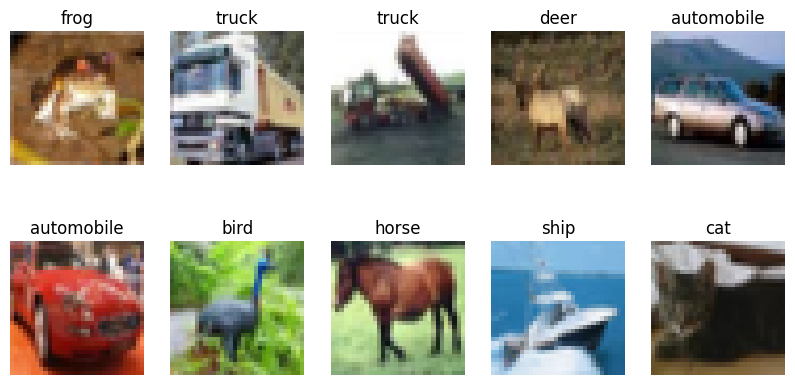

In [6]:
# Visualize the samples
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')
plt.show()

In [7]:
# Prepare Data
from tensorflow.keras.utils import to_categorical

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [9]:
# Build the CNN
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [10]:
# set hyperparameters
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
782/782 - 12s - 15ms/step - accuracy: 0.4342 - loss: 1.5414 - val_accuracy: 0.5181 - val_loss: 1.3376
Epoch 2/15
782/782 - 3s - 4ms/step - accuracy: 0.5683 - loss: 1.2119 - val_accuracy: 0.6197 - val_loss: 1.0806
Epoch 3/15
782/782 - 3s - 4ms/step - accuracy: 0.6232 - loss: 1.0606 - val_accuracy: 0.6554 - val_loss: 0.9793
Epoch 4/15
782/782 - 3s - 4ms/step - accuracy: 0.6592 - loss: 0.9674 - val_accuracy: 0.6697 - val_loss: 0.9148
Epoch 5/15
782/782 - 3s - 4ms/step - accuracy: 0.6901 - loss: 0.8822 - val_accuracy: 0.6945 - val_loss: 0.8687
Epoch 6/15
782/782 - 3s - 4ms/step - accuracy: 0.7110 - loss: 0.8234 - val_accuracy: 0.7045 - val_loss: 0.8404
Epoch 7/15
782/782 - 3s - 4ms/step - accuracy: 0.7309 - loss: 0.7684 - val_accuracy: 0.7283 - val_loss: 0.7810
Epoch 8/15
782/782 - 3s - 4ms/step - accuracy: 0.7452 - loss: 0.7288 - val_accuracy: 0.7286 - val_loss: 0.7972
Epoch 9/15
782/782 - 3s - 4ms/step - accuracy: 0.7592 - loss: 0.6820 - val_accuracy: 0.7388 - val_loss: 0.7524

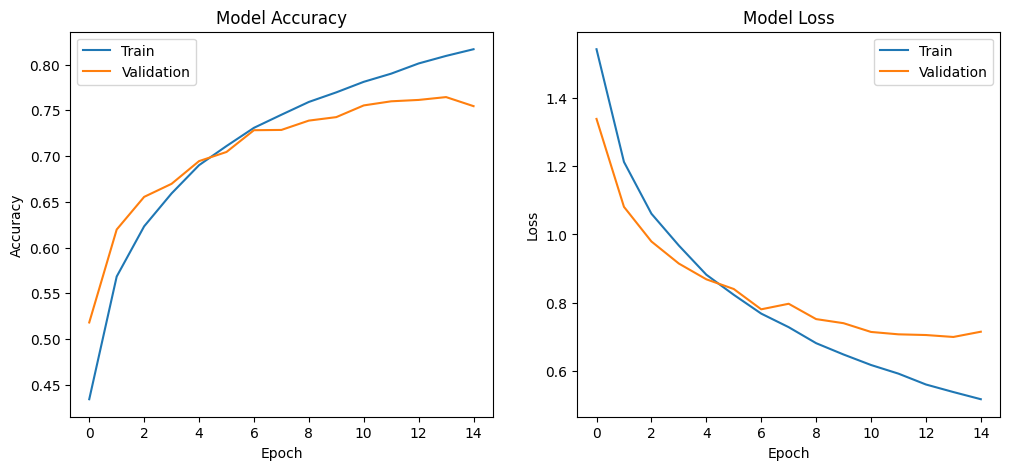

In [13]:
# train the model
history = model.fit(
    x_train, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=2
)

# Plot accuracy/loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()


✅ Test Accuracy: 75.46%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


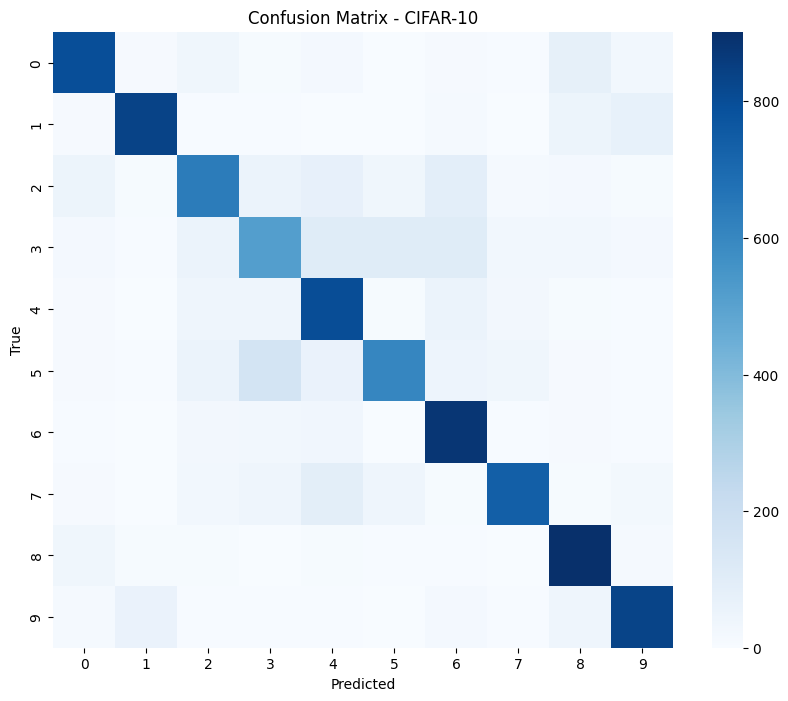

In [15]:
# test & evaluate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")

# Predict classes
y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = y_test.flatten()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - CIFAR-10")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
